# LangChain Reflection Pattern

The key focus here will be to create the function implementations of the main chain which will include:

- Generate a code solution
- Check code imports and code execution and add error messages if any
- Conditional routing to regenerate code by reflecting on the errors if any OR stop generation

### Enter Open AI API Key

In [1]:
from getpass import getpass

OPENAI_KEY = getpass('Enter Open AI API Key: ')

In [2]:
import os

os.environ['OPENAI_API_KEY'] = OPENAI_KEY

### Step1 - Generate Code

In [47]:
import io
from contextlib import redirect_stdout

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field
from colorama import Fore
from colorama import Style

class Code(BaseModel):
    """Schema for code solutions to questions about coding."""

    prefix: str = Field(description="Description of the problem and approach")
    imports: str = Field(description="Just the import statements of the code")
    code: str = Field(description="Code blocks not including import statements")

# LLM
llm = ChatOpenAI(model="gpt-4o", temperature=0)

# -----------------------
# Code Generator
# -----------------------
CODE_GEN_SYS_PROMPT = [
        (
            "system",
            """You are a coding assistant.
                Ensure any code you provide can be executed with all required imports and variables defined.
                Make sure point 3 below has some code to run and execute any code or functions which you define

                Structure your answer as follows:
                  1) a prefix describing the code solution
                  2) the imports (if no imports needed keep it empty string)
                  3) the functioning code blocks

                Here is the user question:""",
        ),
        ("human", "{question}")
]

code_prompt = ChatPromptTemplate.from_messages(CODE_GEN_SYS_PROMPT)
code_chain = code_prompt | llm.with_structured_output(Code)

In [31]:
# Test chain
result = code_chain.invoke({"question":"Write Factorial number logic without recursion"})

In [32]:
print(result.code)

def factorial_iterative(n):
    if n < 0:
        return "Factorial is not defined for negative numbers"
    result = 1
    for i in range(2, n + 1):
        result *= i
    return result

# Example usage:
number = 5
print(f"Factorial of {number} is {factorial_iterative(number)}")

number = 10
print(f"Factorial of {number} is {factorial_iterative(number)}")


### Step 2 - Code Fix Chain

In [48]:
reflection_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a senior python debugger.

Fix the python code based on error.
"""),
    ("human", """
Code:
{code}

Error:
{error}

Fix the code.
""")
])

reflection_chain = reflection_prompt | llm.with_structured_output(Code)

In [49]:
def run_code(code: str):

    buffer = io.StringIO()

    try:
        with redirect_stdout(buffer):
            exec(code, {})

        output = buffer.getvalue()
        return output, None

    except Exception as e:
        return None, str(e)

### Step 3 Reflection Agent

In [50]:

def reflection_agent(question, max_iterations=5):

    print("\nUser Question:\n", question)

    # generate first code
    code = code_chain.invoke({"question": question})

    for i in range(max_iterations):

        print(f"\nIteration {i+1}")
        print(Style.BRIGHT + Fore.CYAN + f"\n{'=' * 50}")
        print(Fore.MAGENTA + f"\nGenerated Code:\n --> {code.code}")
        print(Style.BRIGHT + Fore.CYAN + f"{'=' * 50}\n")

        # execute
        output, error = run_code(code.code)

        # success
        if error is None:
            print("\nExecution Success:\n", output)
            return output

        print(Style.BRIGHT + Fore.RED + f"\n{'=' * 50}")
        print(Style.BRIGHT + Fore.YELLOW + "Execution Error:")
        print(Fore.WHITE + f"{error}")
        print(Style.BRIGHT + Fore.RED + f"{'=' * 50}\n")

        # reflection fix
        code = reflection_chain.invoke({
            "code": code,
            "error": error
        })

    print("\nMax iterations reached")
    return None

In [51]:
reflection_agent(
    {"question":"Write python code to reverse a string and print result"}
)


User Question:
 {'question': 'Write python code to reverse a string and print result'}

Iteration 1


Generated Code:
 --> def reverse_string(s):
    return s[::-1]

# Example usage
original_string = "Hello, World!"
reversed_string = reverse_string(original_string)
print("Original String:", original_string)
print("Reversed String:", reversed_string)


Execution Success:
 Original String: Hello, World!
Reversed String: !dlroW ,olleH



'Original String: Hello, World!\nReversed String: !dlroW ,olleH\n'

In [52]:
reflection_agent(
    {"question":"Write python code to merge and sort the two list here those two list are already sorted respectively. \
     Dont use any inbuilt function"}
)


User Question:
 {'question': 'Write python code to merge and sort the two list here those two list are already sorted respectively.      Dont use any inbuilt function'}

Iteration 1


Generated Code:
 --> def merge_sorted_lists(list1, list2):
    # Initialize pointers for both lists
    i, j = 0, 0
    # Initialize the result list
    merged_list = []
    
    # Traverse both lists
    while i < len(list1) and j < len(list2):
        # Compare elements from both lists and append the smaller one
        if list1[i] < list2[j]:
            merged_list.append(list1[i])
            i += 1
        else:
            merged_list.append(list2[j])
            j += 1
    
    # If there are remaining elements in list1, append them
    while i < len(list1):
        merged_list.append(list1[i])
        i += 1
    
    # If there are remaining elements in list2, append them
    while j < len(list2):
        merged_list.append(list2[j])
        j += 1
    
    return merged_list

# Example usage:
l

'[1, 2, 3, 4, 5, 6, 7, 8]\n'

- LangChain supports procedural reflection using loops, but as the workflow grows with multiple validation steps, agents, and conditional paths, the control logic becomes complex and hard to maintain.

- In LangChain reflection implementations, we pass code + error, but we lose the original problem context, which can cause incorrect fixes.

**The original problem statement**

*So the model only sees*:
- broken code
- error message

*NOT*:
- what user wanted
- constraints
- requirements

### Solution - <span style="color:green">LangGraph</span>

### Build Agent Graph Node Functions¶
The key focus here will be to create the function implementations of the main nodes in our graph which will include:

- Generate a code solution
- Check code imports and code execution and add error messages if any
- Conditional routing to regenerate code by reflecting on the errors if any OR stop generation

In [56]:
from langchain_openai import ChatOpenAI
from langchain.prompts.chat import ChatPromptTemplate
from pydantic import BaseModel, Field


# Initialize GPT-4o
llm = ChatOpenAI(model_name="gpt-4o", temperature=0)

# Prompt
CODE_GEN_SYS_PROMPT = [
        (
            "system",
            """You are a coding assistant.
                Ensure any code you provide can be executed with all required imports and variables defined.
                Make sure point 3 below has some code to run and execute any code or functions which you define

                Structure your answer as follows:
                  1) a prefix describing the code solution
                  2) the imports (if no imports needed keep it empty string)
                  3) the functioning code blocks

                Here is the user question:""",
        )
]

# Data model
class Code(BaseModel):
    """Schema for code solutions to questions about coding."""

    prefix: str = Field(description="Description of the problem and approach")
    imports: str = Field(description="Just the import statements of the code")
    code: str = Field(description="Code blocks not including import statements")

# LLM
code_generator = llm.with_structured_output(Code)

### State Schema

In [57]:
from typing import TypedDict, Annotated, List
from langgraph.graph.message import AnyMessage, add_messages
from langchain_core.messages import HumanMessage

class CodeGenState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        error_flag : Binary flag for control flow to indicate whether test error was tripped
        messages : With user question, error messages, reasoning
        code_solution : Code solution
        attempts : Number of tries
    """
    error_flag: str
    messages: Annotated[List[AnyMessage], add_messages]
    code_solution: str
    attempts: int

### Node 1: Generate Code

In [58]:

def generate_code(state: CodeGenState) -> CodeGenState:
    """Generate code solution from GPT-4o, structured as prefix/imports/code."""
    print("--- GENERATING CODE SOLUTION ---")
    msgs = state["messages"]
    attempts_so_far = state["attempts"]

    # Call code_generation_chain
    code_soln = code_generator.invoke(CODE_GEN_SYS_PROMPT + msgs)

    # We'll record the chain's answer as a new assistant message in conversation.
    new_msg_content = (f"Here is my solution attempt:\n\nDescription: {code_soln.prefix}\n\n"
                       f"Imports: {code_soln.imports}\n\n"
                       f"Code:\n{code_soln.code}")

    msgs.append(("assistant", new_msg_content))
    attempts_so_far += 1

    return {
        "messages": msgs,
        "code_solution": code_soln,
        "attempts": attempts_so_far
    }

### Node 2: Check Code
- We try to exec the imports, then exec the code. If errors occur, we pass them back to the conversation.

In [59]:
def check_code_execution(state: CodeGenState) -> CodeGenState:
    print("--- CHECKING CODE EXECUTION ---")
    msgs = state["messages"]
    code_soln = state["code_solution"]
    imports_str = code_soln.imports
    code_str = code_soln.code
    attempts = state["attempts"]

    # Attempt to import:
    try:
        exec(imports_str)
    except Exception as e:
        # Import failed
        print("---CODE IMPORT CHECK: FAILED---")
        error_msg = f"""Import test failed!
                        Here is the exception trace details:
                        {e}.

                        Please fix the import section."""

        msgs.append(("user", error_msg))
        return {
            "code_solution": code_soln,
            "attempts": attempts,
            "messages": msgs,
            "error_flag": "yes"
        }

    # Attempt to run code:
    try:
        scope = {}
        exec(f"{imports_str}\n{code_str}", scope)
    except Exception as e:
        print("---CODE BLOCK CHECK: FAILED---")
        error_msg =  f"""Your code solution failed the code execution test!
                            Here is the exception trace details:
                            {e}

                            Reflect on this error and your prior attempt to solve the problem.

                            (1) State what you think went wrong with the prior solution
                            (2) try to solve this problem again.

                            Return the FULL SOLUTION.

                            Use the code tool to structure the output with a prefix, imports, and code block."""

        msgs.append(("user", error_msg))
        return {
            "code_solution": code_soln,
            "attempts": attempts,
            "messages": msgs,
            "error_flag": "yes"
        }

    # If no errors:
    print("--- NO ERRORS FOUND ---")
    return {
            "code_solution": code_soln,
            "attempts": attempts,
            "messages": msgs,
            "error_flag": "no"
    }

### Step 3 - Conditional Routing to Decide Next Step

In [60]:
MAX_ATTEMPTS = 3

def decide_next(state: CodeGenState) -> str:
    """If error or attempts < MAX_ATTEMPTS => go generate. Else end."""
    err = state["error_flag"]
    attempts = state["attempts"]
    if err == "no" or attempts >= MAX_ATTEMPTS:
        print("--- DECISION: FINISH ---")
        return "__end__"
    else:
        print("--- DECISION: RETRY ---")
        return "generate_code"

## Reflection Agentic Graph - Build

In [61]:
from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage

graph = StateGraph(CodeGenState)

# Add nodes:
graph.add_node("generate_code", generate_code)
graph.add_node("check_code", check_code_execution)

# Edges:
graph.set_entry_point("generate_code")
graph.add_edge("generate_code", "check_code")
graph.add_conditional_edges(
    "check_code",
    decide_next,
    [END, "generate_code"]
)

coder_agent = graph.compile()


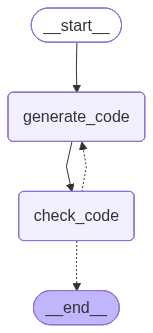

In [62]:
from IPython.display import display, Image, Markdown

display(Image(coder_agent.get_graph().draw_mermaid_png()))

In [63]:
from langchain_core.messages import HumanMessage

def call_reflection_coding_agent(agent, prompt, verbose=False):
    events = agent.stream(
        {"messages": [HumanMessage(content=prompt)], "attempts": 0},
        stream_mode="values",
    )

    print('Running Agent. Please wait...')
    for event in events:
        if verbose:
            event["messages"][-1].pretty_print()

    print('\n\nFinal Solution:')
    print("\nDescription:\n" + event["code_solution"].prefix +
          "\nCode:\n"+event["code_solution"].imports + '\n\n' + event["code_solution"].code)

In [64]:
prompt = """Write python function to:

Find longest palindrome substring
But optimize using O(n) time
Print execution time"""
call_reflection_coding_agent(coder_agent, prompt, verbose=True)

Running Agent. Please wait...
================================ Human Message =================================

Write python function to:

Find longest palindrome substring
But optimize using O(n) time
Print execution time
--- GENERATING CODE SOLUTION ---
================================== Ai Message ==================================

Here is my solution attempt:

Description: To find the longest palindromic substring in O(n) time, we can use Manacher's algorithm. This algorithm transforms the input string to handle even-length palindromes and uses a technique to expand around potential centers efficiently. We'll also measure the execution time using the `time` module.

Imports: import time

Code:
def longest_palindrome_substring(s):
    # Transform the original string to avoid even-length palindrome issues
    T = '#'.join(f'^{s}$')
    n = len(T)
    P = [0] * n
    C = R = 0

    for i in range(1, n - 1):
        mirr = 2 * C - i

        if i < R:
            P[i] = min(R - i, P[m